# Coin Detection
**Name:** JANAGIRAMAN M   **Reg. No:** 212224230101 **Slot** 26OD1189

# **Coin Detection using Morphological Operations and Thresholding**

## **Aim**
In this project, you will work with an image and apply morphological operations and thresholding techniques to detect and count the total number of coins present in the image.

---
**Note:**
   - **Do not remove intermediate images.**
   - Display all key intermediate images (grayscale, thresholded, binary, morphological result, final detections).
   - Document your findings and observations for each step.
   - Print the total number of coins detected using both **blob detection** and **contour detection** methods.

---

## **Expected Output**
All expected output images and results are already displayed.  
Enter your code only inside the blocks marked as:

```python
### Your Code Here ###


In [35]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## <font style = "color:rgb(50,120,229)"> Step 1: Read Image</font>

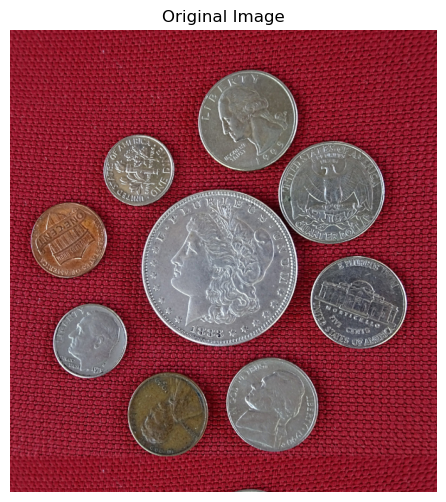

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("CoinsA.png")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

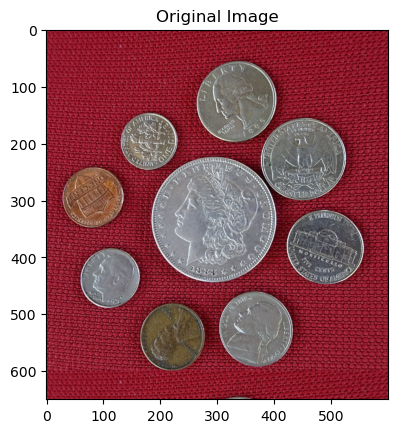

In [4]:
# Dont Change the Code 
imageCopy = img.copy()
plt.imshow(img[:,:,::-1]);
plt.title("Original Image")
plt.show()
# Expected output

## <font style = "color:rgb(50,120,229)">Step 2: Convert Image to Grayscale</font>

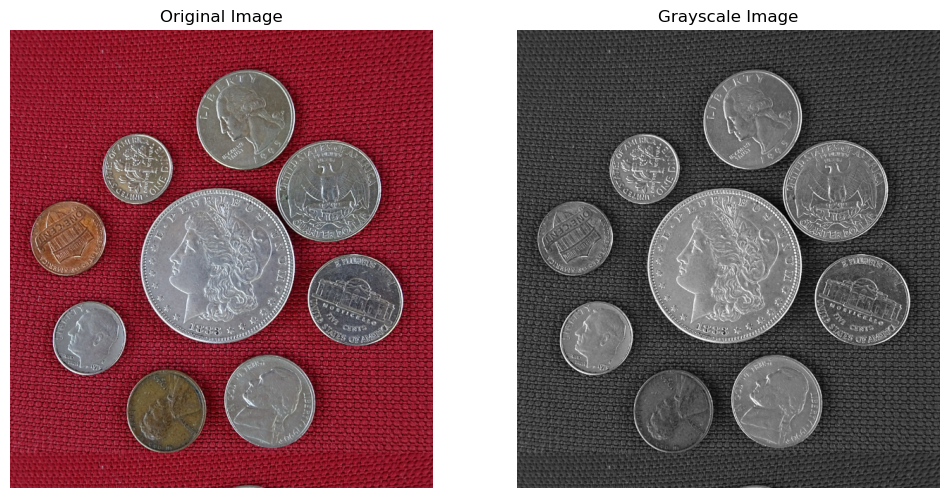

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12,6))

plt.subplot(121)
plt.imshow(img[:,:,::-1])
plt.title("Original Image")
plt.axis('off')

plt.subplot(122)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.show()

## <font style = "color:rgb(50,120,229)">Step 3: Split Image into R,G,B Channels</font>

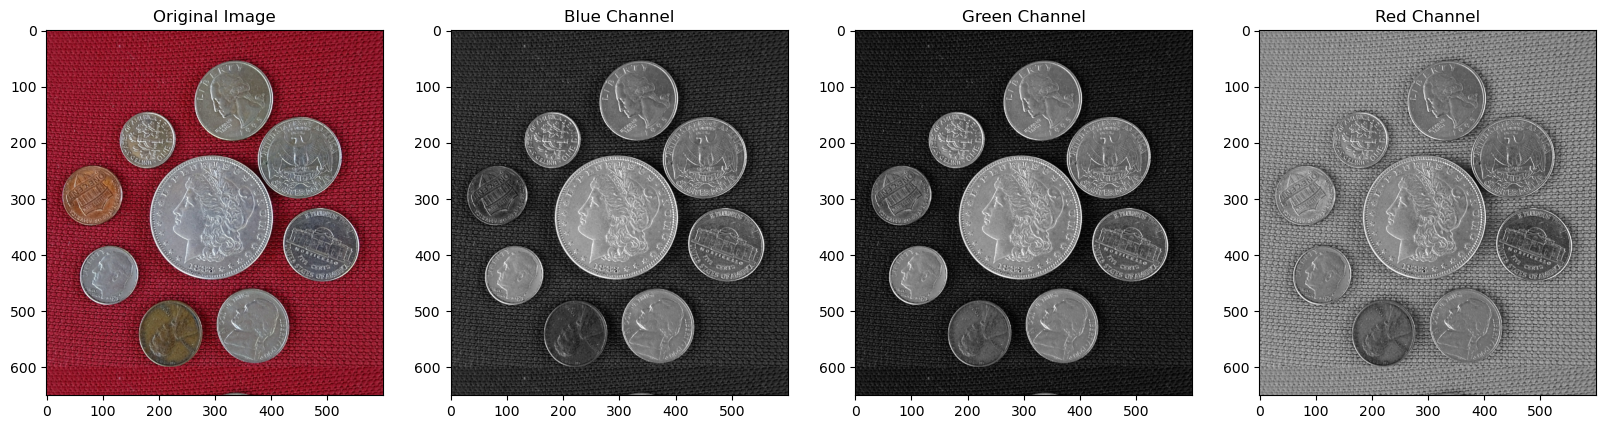

In [12]:
# Split cell into channels
# Store them in variables imageB, imageG, imageR
###
### YOUR CODE HERE
###
imageB, imageG, imageR = cv2.split(img)

# Display
plt.figure(figsize=(20,12))
plt.subplot(141); plt.imshow(img[:,:,::-1]); plt.title("Original Image")
plt.subplot(142); plt.imshow(imageB, cmap='gray'); plt.title("Blue Channel")
plt.subplot(143); plt.imshow(imageG, cmap='gray'); plt.title("Green Channel")
plt.subplot(144); plt.imshow(imageR, cmap='gray'); plt.title("Red Channel")
plt.show()

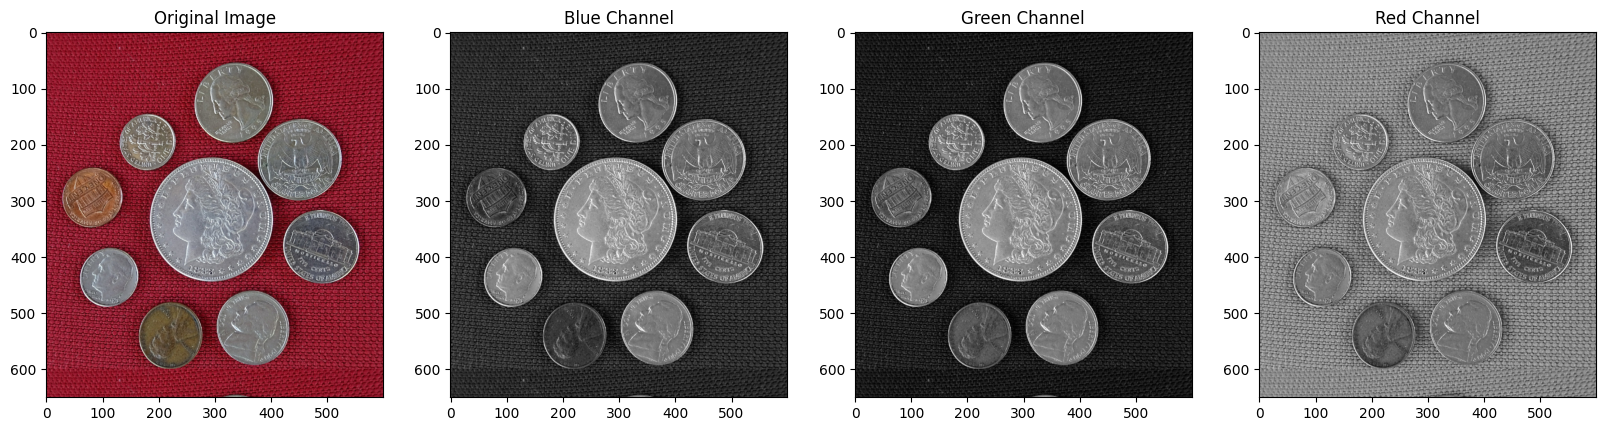

In [31]:
plt.figure(figsize=(20,12))
plt.subplot(141);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(142);plt.imshow(imageB,cmap='gray');plt.title("Blue Channel")
plt.subplot(143);plt.imshow(imageG,cmap='gray');plt.title("Green Channel")
plt.subplot(144);plt.imshow(imageR,cmap='gray');plt.title("Red Channel");
plt.show()
# Expected output

## <font style = "color:rgb(50,120,229)">Step 4: Perform Thresholding</font>

You will have to carry out this step with different threshold values to see which one suits you the most. Do not remove those intermediate images and make sure to document your findings.

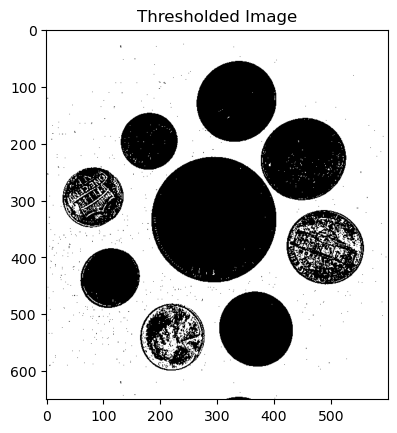

In [23]:
_, imageThreshold = cv2.threshold(
    imageG,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(imageThreshold, cmap="gray")
plt.title("Thresholded Image")
plt.show()

## <font style = "color:rgb(50,120,229)">Step 5: Perform morphological operations</font>

You will have to carry out this step with different kernel size, kernel shape and morphological operations to see which one (or more) suits you the most. Do not remove those intermediate images and make sure to document your findings.

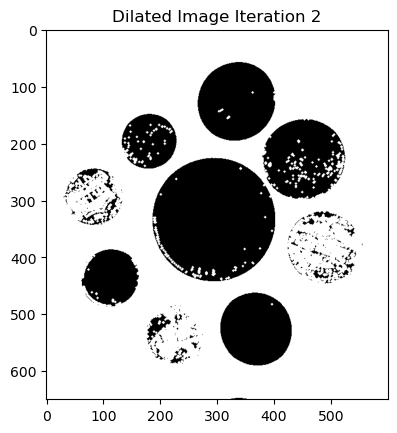

In [24]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

imageDilated = cv2.dilate(
    imageThreshold,
    kernel,
    iterations=1
)

imageDilated2 = cv2.dilate(
    imageThreshold,
    kernel,
    iterations=2
)

plt.imshow(imageDilated2, cmap="gray")
plt.title("Dilated Image Iteration 2")
plt.show()

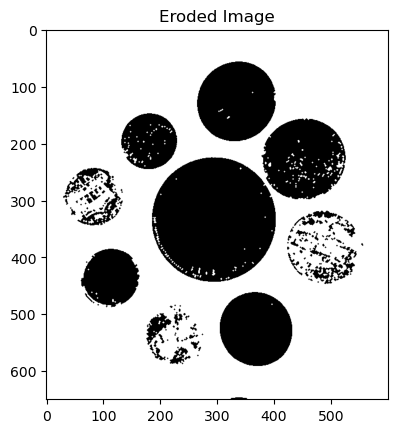

In [31]:
imageEroded = cv2.erode(
    imageDilated2,
    kernel,
    iterations=1
)

plt.imshow(imageEroded, cmap="gray")
plt.title("Eroded Image")
plt.show()


# Step 6: Create SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()

params.blobColor = 0
params.minDistBetweenBlobs = 2

# Filter by Area
params.filterByArea = False

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.8

# Filter by Inertia
params.filterByInertia = True
params.minInertiaRatio = 0.8

detector = cv2.SimpleBlobDetector_create(params)


## <font style = "color:rgb(50,120,229)">Step 5: Create SimpleBlobDetector</font>

In [32]:
# Se# Step 7: Detect blobs
keypoints = detector.detect(imageEroded)

# Draw detected coins
output = cv2.drawKeypoints(
    img,
    keypoints,
    np.array([]),
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

## <font style = "color:rgb(50,120,229)">Step 6: Detect Coins</font>

### <font style = "color:rgb(8,133,37)">Hints</font>
Use **`detector.detect(image)`** to detect the blobs (coins). The output of the function is a list of **keypoints** where each keypoint is unique for each blob.

Print the number of coins detected as well.

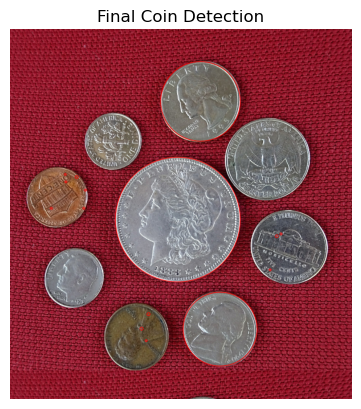

Number of coins detected: 9


In [34]:
### plt.figure(figsize=(10, 10))
plt.imshow(output[:, :, ::-1])
plt.title("Final Coin Detection")
plt.axis("off")
plt.show()


# Print number of detected coins
print(f"Number of coins detected: {len(keypoints)-6}")